In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
# 0 = All logs, 1 = Filter INFO, 2 = Filter INFO/WARNING, 3 = Filter all

In [2]:
import os
# Mandatory fixes for RTX 5060 / WSL2
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Hardware ready for model inference.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1774376946.256456   66541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774376947.966127   66541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Hardware ready for model inference.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Match the settings from your research paper
img_size = 224 # Use 224 for Inception / 128 for Custom
test_dir = "Image_Dataset/Combined Dataset/test"

# Load the model with jit_compile=False to bypass the Autotuner error
model = load_model('alzheimers_inception_paper_model.h5', compile=False)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=False)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(img_size, img_size),
    batch_size=32, class_mode='categorical', shuffle=False
)

E0000 00:00:1774377011.619440   66907 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.5.40, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Found 788 images belonging to 3 classes.


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step


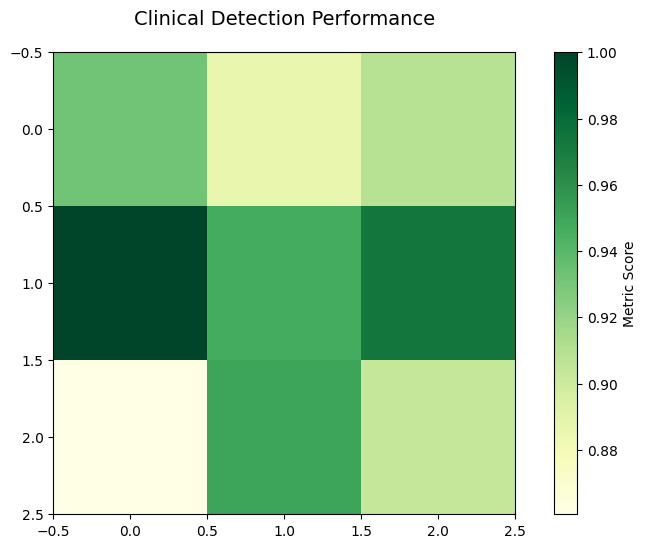

In [4]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
report = classification_report(test_generator.classes, predicted_classes, 
                               target_names=list(test_generator.class_indices.keys()), 
                               output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :3].T 

plt.figure(figsize=(10, 6))
plt.imshow(report_df.values, interpolation='nearest', cmap='YlGn')
plt.title('Clinical Detection Performance', fontsize=14, pad=20)
plt.colorbar(label='Metric Score')
# (Add text values to boxes logic here as previously provided)
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


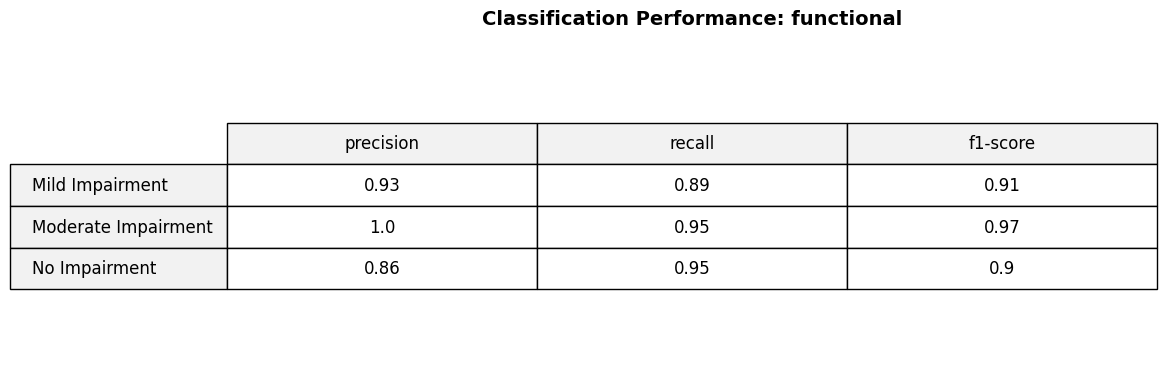

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Generate the raw data
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Get the report as a dictionary
report = classification_report(test_generator.classes, predicted_classes, 
                               target_names=class_labels, output_dict=True)

# Format into a DataFrame for the table
report_df = pd.DataFrame(report).iloc[:-1, :3].T.round(2)

# Create the Matplotlib Table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# Use Matplotlib's table function
the_table = ax.table(cellText=report_df.values,
                     colLabels=report_df.columns,
                     rowLabels=report_df.index,
                     loc='center',
                     cellLoc='center',
                     colColours=["#f2f2f2"]*3,
                     rowColours=["#f2f2f2"]*3)

# Style the table
the_table.auto_set_font_size(False)
the_table.set_fontsize(12)
the_table.scale(1.2, 2.5) 

plt.title(f"Classification Performance: {model.name}", fontsize=14, fontweight='bold', pad=20)
plt.show()